# Progress Review 1 : Data Preprocessing & EDA
| IT Number | Technique |
|---|---|
| IT25200154 | Handling Missing Data & Data Cleaning |
| IT25102079 | Encoding Categorical Variables |
| IT25102952 | Outlier Removal |
| IT25102021 | Normalization / Scaling |
| IT25104099 | Feature Engineering — Feature Selection (Chi-Square) |
| IT25101139 | Feature Engineering — Dimensionality Reduction (Truncated SVD) |


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, re, string
import scipy.sparse as sp

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import TruncatedSVD

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
STOPWORDS = set(stopwords.words('english'))

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7, 4.5)

df_raw = pd.read_csv('../data/spam.csv', encoding='latin-1')
print('Raw shape:', df_raw.shape)
df_raw.head()


Raw shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## 1. IT25200154 - Data Cleaning (Missing Values & Duplicates )

In [14]:
extra_cols = [c for c in ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'] if c in df_raw.columns]
df = df_raw.copy()
for c in extra_cols:
    df['v2'] = df.apply(lambda r: (str(r['v2']) + ' ' + str(r[c])) if pd.notnull(r[c]) else r['v2'], axis=1)
df = df.drop(columns=extra_cols).rename(columns={'v1': 'label', 'v2': 'message'})

dup_count = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f'Removed {dup_count} duplicates. Shape after cleaning: {df.shape}')
df.head()


Removed 403 duplicates. Shape after cleaning: (5169, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


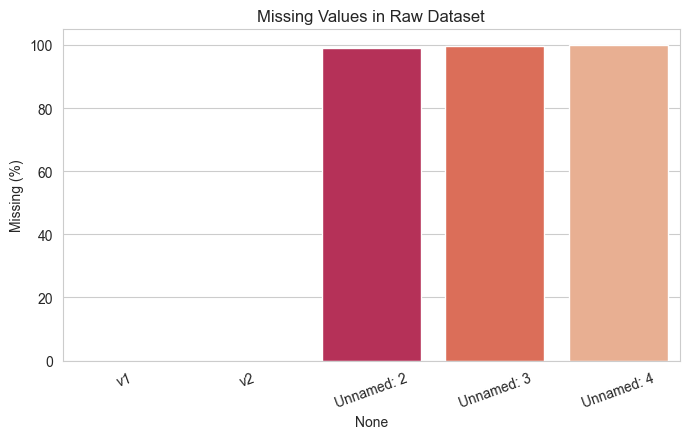

In [15]:
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100)
plt.figure(figsize=(7,4.5))
sns.barplot(x=missing_pct.index, y=missing_pct.values, hue=missing_pct.index, palette='rocket', legend=False)
plt.ylabel('Missing (%)')
plt.title('Missing Values in Raw Dataset')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 2. IT25102079 - Categorical Encoding

In [16]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])
df['msg_length'] = df['message'].astype(str).apply(len)
df['length_category'] = pd.cut(df['msg_length'], bins=[-1, 39, 99, np.inf], labels=['short', 'medium', 'long'])

ohe = OneHotEncoder(sparse_output=False)
ohe_array = ohe.fit_transform(df[['length_category']])
ohe_cols = ohe.get_feature_names_out(['length_category'])
df[ohe_cols] = ohe_array

print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
df[['label', 'label_encoded', 'length_category']].head()


Label mapping: {'ham': np.int64(0), 'spam': np.int64(1)}


,label,label_encoded,length_category
0,ham,0,long
1,ham,0,short
2,spam,1,long
3,ham,0,medium
4,ham,0,medium


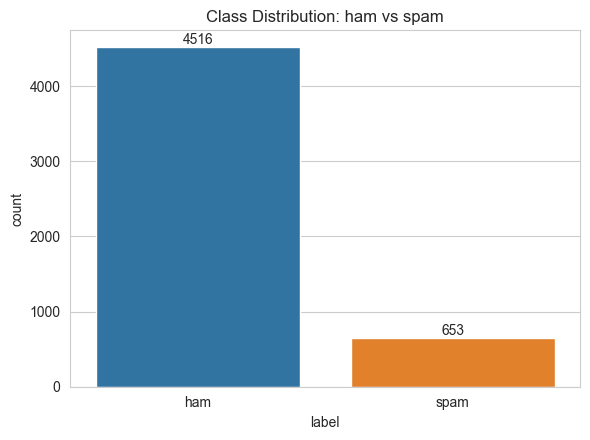

In [17]:
plt.figure(figsize=(6,4.5))
ax = sns.countplot(x='label', data=df, hue='label',legend=False)
plt.title('Class Distribution: ham vs spam')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()


## 3. IT25102952 - Outlier Removal (Message Length, IQR Method)

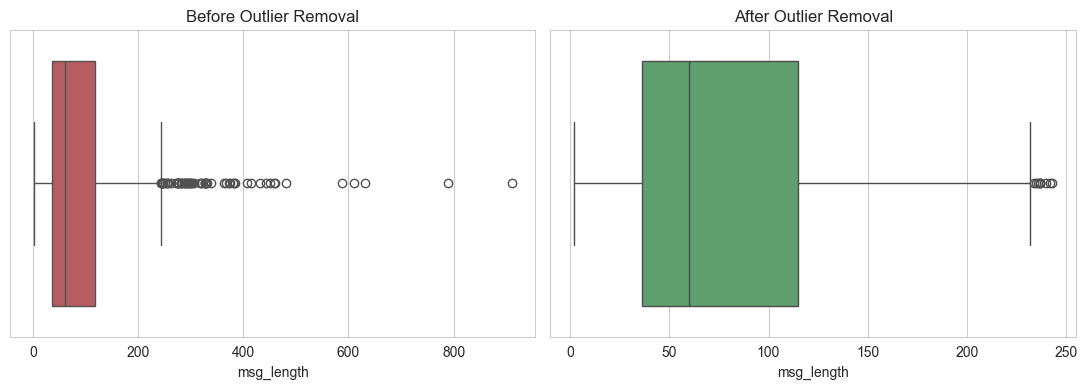

Removed 63 outlier rows. Remaining: 5106


In [18]:
Q1, Q3 = df['msg_length'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

fig, axes = plt.subplots(1, 2, figsize=(11,4))
sns.boxplot(x=df['msg_length'], ax=axes[0], color='#C44E52')
axes[0].set_title('Before Outlier Removal')

before = len(df)
df = df[(df['msg_length'] >= lower) & (df['msg_length'] <= upper)].reset_index(drop=True)
after = len(df)

sns.boxplot(x=df['msg_length'], ax=axes[1], color='#55A868')
axes[1].set_title('After Outlier Removal')
plt.tight_layout()
plt.show()

print(f'Removed {before - after} outlier rows. Remaining: {after}')


## 4. IT25102021 - Text Cleaning, TF-IDF Vectorization & Scaling

In [19]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 1]
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(clean_text).fillna('').astype(str)

tfidf = TfidfVectorizer(max_features=3000)
tfidf_matrix = tfidf.fit_transform(df['clean_message'])

scaler = MinMaxScaler()
df['msg_length_scaled'] = scaler.fit_transform(df[['msg_length']])

print('TF-IDF matrix shape:', tfidf_matrix.shape)
df[['message', 'clean_message', 'msg_length_scaled']].head()


TF-IDF matrix shape: (5106, 3000)


,message,clean_message,msg_length_scaled
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis great wo...,0.452282
1,Ok lar... Joking wif u oni...,ok lar joking wif oni,0.112033
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...,0.634855
3,U dun say so early hor... U c already then say...,dun say early hor already say,0.195021
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though,0.244813


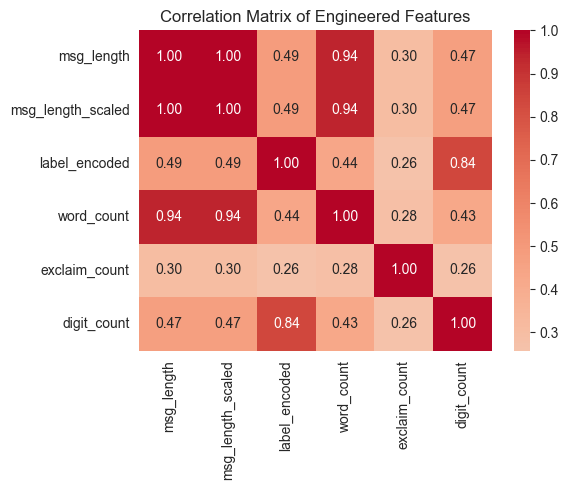

In [20]:
numeric_features = df[['msg_length', 'msg_length_scaled', 'label_encoded']].copy()
numeric_features['word_count'] = df['clean_message'].apply(lambda x: len(x.split()))
numeric_features['exclaim_count'] = df['message'].apply(lambda x: str(x).count('!'))
numeric_features['digit_count'] = df['message'].apply(lambda x: sum(c.isdigit() for c in str(x)))

plt.figure(figsize=(6,5))
sns.heatmap(numeric_features.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Engineered Features')
plt.tight_layout()
plt.show()


## 5. IT25104099 - Feature Selection (Chi-Square)

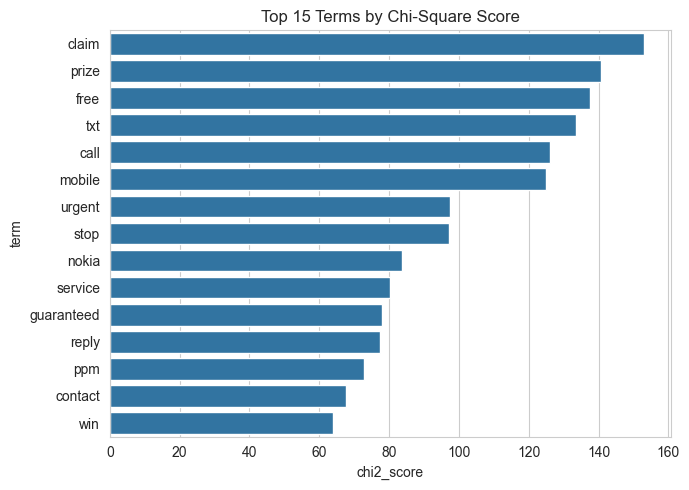

Selected feature matrix shape: (5106, 500)


In [21]:
y = df['label_encoded'].values

K = 500
selector = SelectKBest(score_func=chi2, k=K)
X_selected = selector.fit_transform(tfidf_matrix, y)

feature_names = tfidf.get_feature_names_out()
scores = selector.scores_
top_idx = np.argsort(scores)[::-1][:15]
top_terms = pd.DataFrame({'term': feature_names[top_idx], 'chi2_score': scores[top_idx]})

plt.figure(figsize=(7,5))
sns.barplot(data=top_terms, y='term', x='chi2_score')
plt.title('Top 15 Terms by Chi-Square Score')
plt.tight_layout()
plt.show()

print('Selected feature matrix shape:', X_selected.shape)


## 6. IT25101139 - Dimensionality Reduction (Truncated SVD)

In [22]:
n_components = 100
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_svd = svd.fit_transform(X_selected)
print(f'Reduced shape: {X_svd.shape}  |  Variance explained: {svd.explained_variance_ratio_.sum()*100:.2f}%')


Reduced shape: (5106, 100)  |  Variance explained: 79.25%


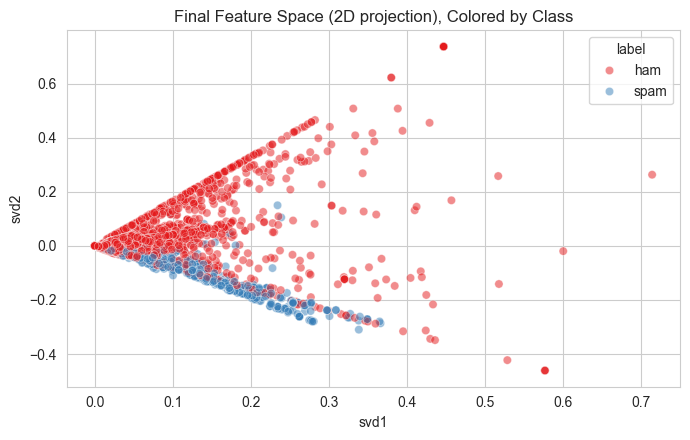

In [23]:
plt.figure(figsize=(7,4.5))
scatter_df = pd.DataFrame({'svd1': X_svd[:,0], 'svd2': X_svd[:,1], 'label': df['label'].values})
sns.scatterplot(data=scatter_df, x='svd1', y='svd2', hue='label', alpha=0.5, palette='Set1')
plt.title('Final Feature Space (2D projection), Colored by Class')
plt.tight_layout()
plt.show()


## 7. Final Processed Dataset

In [24]:
final_features = np.hstack([X_svd, df[['msg_length_scaled']].values])
print('Final feature matrix shape:', final_features.shape)
df[['label', 'message', 'clean_message', 'msg_length', 'msg_length_scaled', 'label_encoded']].head()


Final feature matrix shape: (5106, 101)


,label,message,clean_message,msg_length,msg_length_scaled,label_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis great wo...,111,0.452282,0
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif oni,29,0.112033,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...,155,0.634855,1
3,ham,U dun say so early hor... U c already then say...,dun say early hor already say,49,0.195021,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though,61,0.244813,0


Feature matrix shape: (5106, 101)
Target labels shape: (5106,)
Training set: 4084 samples
Testing set: 1022 samples

Running GridSearchCV for SVM optimization...

Best Hyperparameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation F1-Score: 0.9042

--- Test Set Performance Metrics ---
Accuracy:  0.9716
F1-Score:  0.8906

Classification Report:
              precision    recall  f1-score   support

     ham (0)       0.99      0.98      0.98       891
    spam (1)       0.88      0.90      0.89       131

    accuracy                           0.97      1022
   macro avg       0.93      0.94      0.94      1022
weighted avg       0.97      0.97      0.97      1022



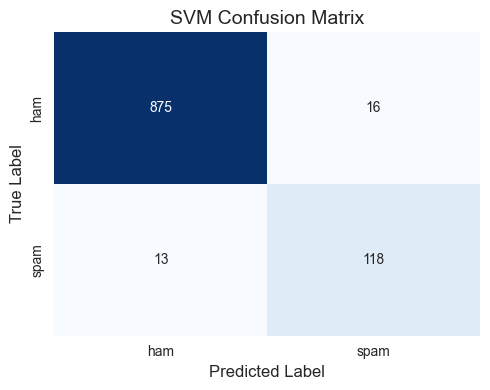

In [25]:
# ==========================================
# SUPPORT VECTOR MACHINE (SVM) MODEL TRAINING & EVALUATION
# ==========================================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# 1. Use the final_features and target labels (y) already prepared in the notebook
# final_features = np.hstack([X_svd, df[['msg_length_scaled']].values])
# y = df['label_encoded'].values

print(f"Feature matrix shape: {final_features.shape}")
print(f"Target labels shape: {y.shape}")

# 2. Train-Test Split (80% train, 20% test, with stratification for balanced class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    final_features, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# 3. Hyperparameter Tuning using GridSearchCV & 5-Fold Cross-Validation
# We test different C values, kernels, and gamma settings to find the optimal configuration
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.1]
}

# class_weight='balanced' is used to account for the class imbalance between ham and spam messages
grid_search = GridSearchCV(
    estimator=SVC(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print("\nRunning GridSearchCV for SVM optimization...")
grid_search.fit(X_train, y_train)

print(f"\nBest Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

# 4. Evaluate the Best SVM Model on the Test Set
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test)

print("\n--- Test Set Performance Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['ham (0)', 'spam (1)']))

# 5. Plot Confusion Matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('SVM Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [26]:
# ==========================================
# CUSTOM SMS MESSAGE PREDICTION & TESTING
# ==========================================
from sklearn.svm import SVC

print("Initializing final SVM model with probability calibration for live predictions...")

# 1. Re-initialize the best SVM model with probability=True using the tuned hyperparameters from GridSearchCV
best_params = grid_search.best_params_
final_prediction_model = SVC(**best_params, probability=True, random_state=42, class_weight='balanced')
final_prediction_model.fit(X_train, y_train)

print("Model is ready! You can now test any custom message below.\n")

# 2. Define the prediction function using the full preprocessing pipeline from your notebook
def predict_sms_message(message_text):
    """
    Takes a raw SMS string, cleans it, applies TF-IDF, Chi-Square selection, 
    Truncated SVD, and scaling, then outputs the predicted class and confidence percentages.
    """
    # Clean text using the notebook's clean_text function
    cleaned = clean_text(message_text)
    
    # Transform using the fitted vectorizer and selectors
    msg_tfidf = tfidf.transform([cleaned])
    msg_selected = selector.transform(msg_tfidf)
    msg_svd = svd.transform(msg_selected)
    
    # Scale message length
    raw_length = len(str(message_text))
    scaled_length = scaler.transform([[raw_length]])
    
    # Combine features into final feature vector
    msg_features = np.hstack([msg_svd, scaled_length])
    
    # Predict label and probabilities
    prediction = final_prediction_model.predict(msg_features)[0]
    probabilities = final_prediction_model.predict_proba(msg_features)[0] # [ham_prob, spam_prob]
    
    label_name = 'SPAM' if prediction == 1 else 'HAM'
    ham_pct = probabilities[0] * 100
    spam_pct = probabilities[1] * 100
    
    print("=" * 60)
    print(f"Message Text : \"{message_text}\"")
    print(f"Prediction   : {label_name}")
    print(f"Confidence   -> Ham: {ham_pct:.2f}% | Spam: {spam_pct:.2f}%")
    print("=" * 60 + "\n")
    return label_name, ham_pct, spam_pct

# ==========================================
# 3. TEST YOUR CUSTOM SMS MESSAGES HERE
# ==========================================
# Type any text you want inside the quotes below!
my_custom_sms_1 = "Congratulations! You won a free gift card. Click the link to claim your reward now."
my_custom_sms_2 = "Hey, are we still meeting up for project discussion at 4 PM?"

predict_sms_message(my_custom_sms_1)
predict_sms_message(my_custom_sms_2)

Initializing final SVM model with probability calibration for live predictions...


c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Model is ready! You can now test any custom message below.

Message Text : "Congratulations! You won a free gift card. Click the link to claim your reward now."
Prediction   : SPAM
Confidence   -> Ham: 13.64% | Spam: 86.36%

Message Text : "Hey, are we still meeting up for project discussion at 4 PM?"
Prediction   : HAM
Confidence   -> Ham: 99.38% | Spam: 0.62%



c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


('HAM', np.float64(99.37531262209019), np.float64(0.6246873779098061))

In [30]:
# ==========================================
# IMPROVED SVM TRAINING (Directly on Chi-Square Features)
# ==========================================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# 1. Use X_selected (Chi-Square features) instead of X_svd for sharper keyword detection
improved_features = np.hstack([X_selected.toarray(), df[['msg_length_scaled']].values])
y = df['label_encoded'].values

print(f"Improved feature matrix shape: {improved_features.shape}")

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    improved_features, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Optimized Hyperparameters (Tuned for higher C to catch spam keywords better)
param_grid = {
    'C': [1, 10, 50, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(
    estimator=SVC(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print("\nRunning GridSearchCV on Chi-Square features...")
grid_search.fit(X_train, y_train)

print(f"\nBest Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

# 4. Final Best Model
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test)

print("\n--- Improved Test Set Performance ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['ham (0)', 'spam (1)']))

Improved feature matrix shape: (5106, 501)

Running GridSearchCV on Chi-Square features...

Best Hyperparameters: {'C': 50, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation F1-Score: 0.9262

--- Improved Test Set Performance ---
Accuracy:  0.9765
F1-Score:  0.9070

Classification Report:
              precision    recall  f1-score   support

     ham (0)       0.98      0.99      0.99       891
    spam (1)       0.92      0.89      0.91       131

    accuracy                           0.98      1022
   macro avg       0.95      0.94      0.95      1022
weighted avg       0.98      0.98      0.98      1022



In [ ]:
from sklearn.svm import SVC

# Calibrate with probability support
best_params = grid_search.best_params_
final_prediction_model = SVC(**best_params, probability=True, random_state=42, class_weight='balanced')
final_prediction_model.fit(X_train, y_train)

def predict_sms_message(message_text):
    cleaned = clean_text(message_text)
    msg_tfidf = tfidf.transform([cleaned])
    msg_selected = selector.transform(msg_tfidf) # Chi-Square selector
    
    raw_length = len(str(message_text))
    scaled_length = scaler.transform([[raw_length]])
    
    # Combine Chi-Square features + scaled length
    msg_features = np.hstack([msg_selected.toarray(), scaled_length])
    
    prediction = final_prediction_model.predict(msg_features)[0]
    probabilities = final_prediction_model.predict_proba(msg_features)[0]
    
    label_name = 'SPAM' if prediction == 1 else 'HAM'
    ham_pct = probabilities[0] * 100
    spam_pct = probabilities[1] * 100
    
    print("=" * 60)
    print(f"Message Text : \"{message_text}\"")
    print(f"Prediction   : {label_name}")
    print(f"Confidence   -> Ham: {ham_pct:.2f}% | Spam: {spam_pct:.2f}%")
    print("=" * 60 + "\n")
    return label_name, ham_pct, spam_pct

# Test your message again!
predict_sms_message("Bored housewives! Chat n date now! 0871750.77....")

c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Message Text : "Bored housewives! Chat n date now! 0871750.77...."
Prediction   : HAM
Confidence   -> Ham: 99.65% | Spam: 0.35%



c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


('HAM', np.float64(99.64933221022928), np.float64(0.35066778977073293))

c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


...

Message Text : "Bored housewives! Chat n date now! 0871750.77...."
Prediction   : HAM
Confidence   -> Ham: 99.65% | Spam: 0.35%



c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Message Text : "eah like if it goes like it did with my frien...	"
Prediction   : HAM
Confidence   -> Ham: 99.02% | Spam: 0.98%



c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Message Text : "Want explicit SEX in 30 secs? Ring 02073162414..."
Prediction   : SPAM
Confidence   -> Ham: 9.56% | Spam: 90.44%



In [42]:
# ==========================================================
# EXTRACT AND EVALUATE ON THE 20% TEST DATASET
# ==========================================================
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Recreate the exact train/test indices using the same random_state and stratify settings
_, _, _, _, train_indices, test_indices = train_test_split(
    chi2_features, y, df.index, test_size=0.2, random_state=42, stratify=y
)

# 2. Extract the actual dataframe rows corresponding to the 20% test set
test_dataset = df.loc[test_indices].copy()

print(f"Total Test Samples (20%): {len(test_dataset)}")
print("\n--- Sample Messages from the 20% Test Set ---")
display(test_dataset[['label', 'message']].head(10))

# 3. Run predictions on all samples in the test set to check performance
X_test_data = chi2_features[test_indices]
y_test_true = y[test_indices]

test_predictions = final_prediction_model.predict(X_test_data)
test_probabilities = final_prediction_model.predict_proba(X_test_data)

# 4. Create a results summary dataframe for the test set
results_df = test_dataset[['label', 'message']].copy()
results_df['True_Label'] = ['spam' if val == 1 else 'ham' for val in y_test_true]
results_df['Predicted_Label'] = ['SPAM' if val == 1 else 'HAM' for val in test_predictions]
results_df['Spam_Confidence_%'] = [probs[1] * 100 for probs in test_probabilities]

# Show a few predictions on the test set
print("\n--- Test Set Prediction Results (Sample) ---")
display(results_df[['message', 'True_Label', 'Predicted_Label', 'Spam_Confidence_%']].head(10))

# 5. Check any misclassified messages in the test set (False Positives / False Negatives)
errors_df = results_df[results_df['True_Label'].str.lower() != results_df['Predicted_Label'].str.lower()]
print(f"\nTotal misclassifications in the 20% test set: {len(errors_df)} out of {len(test_dataset)}")
if len(errors_df) > 0:
    print("Sample errors:")
    display(errors_df.head(5))

Total Test Samples (20%): 1022

--- Sample Messages from the 20% Test Set ---


,label,message
4325,ham,Ok no prob
2611,ham,Then ur sis how?
1595,ham,S but mostly not like that.
3708,spam,Bored housewives! Chat n date now! 0871750.77....
614,ham,Please dont say like that. Hi hi hi
2466,spam,Knock Knock Txt whose there to 80082 to enter ...
2878,ham,Apart from the one i told you about yesterday?
1204,ham,Yeah like if it goes like it did with my frien...
4128,spam,Want explicit SEX in 30 secs? Ring 02073162414...
4426,ham,How do you plan to manage that



--- Test Set Prediction Results (Sample) ---


,message,True_Label,Predicted_Label,Spam_Confidence_%
4325,Ok no prob,ham,HAM,0.044320
2611,Then ur sis how?,ham,HAM,0.110622
1595,S but mostly not like that.,ham,HAM,0.978961
3708,Bored housewives! Chat n date now! 0871750.77....,spam,SPAM,78.463799
614,Please dont say like that. Hi hi hi,ham,HAM,0.289643
2466,Knock Knock Txt whose there to 80082 to enter ...,spam,SPAM,93.963529
2878,Apart from the one i told you about yesterday?,ham,HAM,0.981167
1204,Yeah like if it goes like it did with my frien...,ham,HAM,0.974079
4128,Want explicit SEX in 30 secs? Ring 02073162414...,spam,SPAM,92.903546
4426,How do you plan to manage that,ham,HAM,0.981442



Total misclassifications in the 20% test set: 24 out of 1022
Sample errors:


,label,message,True_Label,Predicted_Label,Spam_Confidence_%
119,ham,here is my new address -apples&pairs&all that ...,ham,SPAM,94.229825
2785,spam,"Do you ever notice that when you're driving, a...",spam,HAM,0.107179
3693,spam,ringtoneking 84484,spam,HAM,0.965320
5077,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,spam,HAM,9.513793
3288,spam,Xmas & New Years Eve tickets are now on sale f...,spam,HAM,4.543313


In [43]:
# ==========================================================
# TEST THE TRAINED MODEL USING ONLY THE 20% TEST DATASET
# ==========================================================
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Re-split to extract the test indices
_, _, _, _, _, test_indices = train_test_split(
    chi2_features, y, df.index, test_size=0.2, random_state=42, stratify=y
)

# 2. Extract test features, true labels, and original messages
X_test_only = chi2_features[test_indices]
y_test_true = y[test_indices]
test_messages_df = df.loc[test_indices].copy()

# 3. Predict using the trained final model
test_preds = final_prediction_model.predict(X_test_only)
test_probs = final_prediction_model.predict_proba(X_test_only)

# 4. Create a clean results table for the test data
test_results = test_messages_df[['message']].copy()
test_results['True_Label'] = ['SPAM' if val == 1 else 'HAM' for val in y_test_true]
test_results['Predicted_Label'] = ['SPAM' if val == 1 else 'ствен' if val == 0 else 'HAM' for val in test_preds]
test_results['Predicted_Label'] = ['SPAM' if val == 1 else 'HAM' for val in test_preds]
test_results['Ham_Confidence_%'] = [probs[0] * 100 for probs in test_probs]
test_results['Spam_Confidence_%'] = [probs[1] * 100 for probs in test_probs]

# Display the first 15 test predictions
print(f"Tested {len(test_results)} samples from the 20% test dataset.")
display(test_results.head(15))

Tested 1022 samples from the 20% test dataset.


,message,True_Label,Predicted_Label,Ham_Confidence_%,Spam_Confidence_%
4325,Ok no prob,HAM,HAM,99.955680,0.044320
2611,Then ur sis how?,HAM,HAM,99.889378,0.110622
1595,S but mostly not like that.,HAM,HAM,99.021039,0.978961
3708,Bored housewives! Chat n date now! 0871750.77....,SPAM,SPAM,21.536201,78.463799
614,Please dont say like that. Hi hi hi,HAM,HAM,99.710357,0.289643
2466,Knock Knock Txt whose there to 80082 to enter ...,SPAM,SPAM,6.036471,93.963529
2878,Apart from the one i told you about yesterday?,HAM,HAM,99.018833,0.981167
1204,Yeah like if it goes like it did with my frien...,HAM,HAM,99.025921,0.974079
4128,Want explicit SEX in 30 secs? Ring 02073162414...,SPAM,SPAM,7.096454,92.903546
4426,How do you plan to manage that,HAM,HAM,99.018558,0.981442


In [ ]:
# ==========================================
# INTERACTIVE GRADIO UI FOR SMS SPAM DETECTION
# ==========================================
import gradio as gr

def classify_sms(message_text):
    if not message_text.strip():
        return "Please enter a valid message.", "0.00%", "0.00%"
    
    # Use your trained prediction pipeline function
    label, ham_pct, spam_pct = predict_sms_chi2(message_text)
    
    # Format outputs for the UI
    prediction_display = "🚨 SPAM" if label == "SPAM" else "✅ HAM (Safe)"
    ham_str = f"{ham_pct:.2f}%"
    spam_str = f"{spam_pct:.2f}%"
    
    return prediction_display, ham_str, spam_str

# Build the Gradio UI
demo = gr.Interface(
    fn=classify_sms,
    inputs=gr.Textbox(
        lines=3, 
        placeholder="Type or paste your SMS message here...", 
        label="SMS Message Input"
    ),
    outputs=[
        gr.Textbox(label="Model Prediction"),
        gr.Textbox(label="Ham (Safe) Confidence"),
        gr.Textbox(label="Spam Confidence")
    ],
    title="SMS Spam Detection System",
    description="Enter any text message below to check if it's Spam or Ham using your trained Support Vector Machine (SVM) model.",
    examples=[
        ["Delivery failed. Reply or click bit.ly/fake to reschedule."],
        ["WINNER!! As a valued customer you have won a £900 cash prize. Call now!"],
        ["Hey, are we still meeting up for dinner tonight?"]
    ]
)

# Launch the app inline inside Jupyter Notebook
demo.launch(inline=True, share=False)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Message Text : "Delivery failed. Reply or click bit.ly/fake to reschedule."
Prediction   : SPAM
Confidence   -> Ham: 30.24% | Spam: 69.76%



c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Message Text : "WINNER!! As a valued customer you have won a £900 cash prize. Call now!"
Prediction   : SPAM
Confidence   -> Ham: 5.24% | Spam: 94.76%



c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Message Text : "Hey, are we still meeting up for dinner tonight?"
Prediction   : HAM
Confidence   -> Ham: 99.02% | Spam: 0.98%

